## Profiling the Hermes Agent on AMD

This is a hands-on, **beginner-friendly** tutorial. [Hermes Agent](https://hermes-agent.nousresearch.com/docs/getting-started/quickstart) is an open-source, autonomous AI agent framework by Nous Research. Unlike a plain chatbot, an *agent* can **plan, pick tools, and finish multi-step tasks on its own**. It decides which tools to call, and in what order, to reach a goal. 

> **New to agents? Two words to know first:**
>
> - **Tool** - a single action the agent can perform, exposed as a function it can call (for example, "convert this text to speech" or "read a file"). For each step, the agent picks the tool that fits. 
> - **Skill** - a higher-level, reusable ability, usually a packaged set of instructions that may combine several tools to handle a larger task.
>
> The key idea: Hermes ships with built-in tools, and you can also **add your own**. The Kokoro text-to-speech tool we use here is a custom tool added to Hermes this way.

When an agent runs, some steps are fast and some are slow. **Profiling** is how we measure each step so we can see exactly where the time goes.

This matters because an agent is only as fast as the tools it calls. A single slow tool can dominate an entire run, even when the model itself is quick. Finding and fixing that one tool is often the difference between a sluggish agent and a responsive one.


## What you'll learn

By the end of this session you will be able to:

- Run a Hermes agent and capture its telemetry
- Read the telemetry dashboard to spot a slow tool
- Swap in an optimized version of that tool
- Compare before and after, and see how hardware usage changes


## Our example workflow

```
Text File
    |
    v
Hermes Agent
    |
    v
TTS Tool
    |
    v
Audio Output
```

Keep one thing in mind throughout: The focus here is **profiling and optimization**. Text-to-speech is just the example to show the bottleneck and the optimization.

## Prerequisites

This tutorial was developed and tested using the following setup.

### Operating system

**Ubuntu 22.04 / 24.04:** Ensure your system is running Ubuntu 22.04 or 24.04.

### Hardware

**AMD Instinct™ MI300X GPU:** This tutorial was tested on a single AMD Instinct MI300X GPU (192 GB VRAM), which comfortably hosts both the Muse-Glimmer-30B model and the Kokoro TTS model. Ensure you are using an AMD Instinct GPU with ROCm support and that your system meets the official requirements.

### Software

**ROCm 7.2:** Install and verify ROCm by following the ROCm install guide. After installation, confirm your setup using:

```bash
amd-smi
```

This command lists your AMD GPUs with relevant details.

> **Note:** For ROCm 6.4 and earlier, use the `rocm-smi` command instead.

**Docker:** Ensure Docker is installed and configured correctly. Follow the Docker installation guide for your operating system. The workshop runs the model and GPU-metrics services in containers with access to `/dev/kfd` and `/dev/dri`.

> **Note:** Ensure Docker permissions are correctly configured. To allow non-root access, run:
>
> ```bash
> sudo usermod -aG docker $USER
> newgrp docker
> ```
>
> Verify Docker is working correctly with:
>
> ```bash
> docker run hello-world
> ```

**vLLM ROCm image:** The agent's model is served with vLLM, using AMD's prebuilt **`vllm/vllm-openai-rocm:nightly`** image as the base. Muse-Glimmer-30B support is not yet in a released vLLM, so on the first run `helper.sh` overlays the vLLM code from [pull request #51655](https://github.com/vllm-project/vllm/pull/51655) (a Python-only change that adds Muse-Glimmer) onto that nightly image and commits the result as a local image, **`vllm-muse-glimmer:rocm`**, which then serves the model. This build happens automatically and only once. AMD also provides other prebuilt ROCm images (PyTorch, Ubuntu 22.04 / 24.04) you can reuse for ROCm work.

**Python 3.12 and JupyterLab:** Python 3.12 (with `venv` and `pip`) runs the Kokoro server, MLflow, and this notebook. Launch this notebook from JupyterLab in that same environment.

**Everything else is installed for you by `helper.sh`** - MLflow, the Hermes agent and its `hermes-otel` plugin, PyTorch (ROCm 7.2), Kokoro, FastAPI / Uvicorn, Streamlit, and Matplotlib. You only need internet access on the first run (to pull the base image, download the model, and install packages), and a Hugging Face token if the model is gated.

## Before You Begin

A single script starts everything for you. Open a separate terminal and run:

```bash
bash helper.sh
```

Leave that terminal open for the whole tutorial. The script starts the services and then stays alive to keep them running. If you close it, the backend shuts down.

> **Run this in a separate terminal, not in a notebook cell.** The script runs continuously, so a notebook cell would sit blocked and never finish.



## What helper.sh does

You do not need to set anything up by hand. `helper.sh` launches the full backend so you can focus entirely on profiling instead of installation and configuration.

Behind the scenes it brings up:

| Service | Role |
| :--- | :--- |
| **Hermes backend** (vLLM · Meta's Muse-Glimmer-30B) | The agent's "brain", the model that plans and picks tools |
| **MLflow tracking server** | Records every run, including timings and hardware metrics |
| **Telemetry dashboard** | The web page where you will visualize each run |
| **Kokoro TTS server** | The local text-to-speech engine used later in the workshop |
| **Supporting services** | GPU metrics collection and the other pieces Hermes needs |

> **About the model:** **Meta's Muse-Glimmer-30B** is a dense vision-language model built for agentic work on consumer hardware: a 52-layer text decoder (hidden 6656) plus a ~1.8B ViT-G/14 perception encoder, 128K trained context, BF16. Apache 2.0, knowledge cutoff January 4 2026, trained on 100+ languages.

When the script finishes starting up, it prints a set of URLs in that terminal. You will use those URLs in the next section, so keep the terminal visible.

## Check Your Setup

Before sending the agent any work, confirm the `hermes` command is available in this notebook's environment. The next cell prints the path to the Hermes binary and then `Hermes is ready.`

> **If nothing prints,** the notebook cannot find Hermes on its `PATH`. Make sure `helper.sh` has finished starting up, and that Jupyter was launched from the same environment.

In [ ]:
!which hermes && echo "Hermes is ready."

## Step 1 - Baseline: Edge TTS

Every profiling exercise needs a starting point. Ours is **Edge TTS**, the text-to-speech provider Hermes uses by default.

Edge is cloud-based and needs no local setup. Hermes sends text to the service and receives audio back. That makes it a convenient baseline: nothing to install, nothing to configure.

The following command asks the agent to read `input_text.txt` and speak it using only the built-in Edge tool. We pin it to Edge on purpose so the baseline stays clean and comparable.

In [ ]:
!hermes chat --yolo -q "Convert the text in the file input_text.txt into speech using ONLY the built-in text_to_speech tool (default Edge provider). Do not use the kokoro_tts tool, and do not check the length or switch tools — even if the text is long, call text_to_speech directly on the full text and save the audio file."

**Listen to the Generated Audio**

If the generated audio is stored in `~/.hermes/audio_cache`. Copy it to the notebook's `outputs` folder:

```bash
cp /path/to/generated_audio.wav outputs/
```

Then open the **`outputs`** folder and click the audio file to play it.

### Observations

Look at the audio Edge produced and note a few things:

- Edge caps long inputs at roughly five minutes of audio.
- This happens no matter how long the input text is, the tail simply gets cut off.
- For short inputs, Edge works well and is perfectly convenient.
- Because it is cloud-based, the text you send leaves your machine.

For privacy-sensitive work, keeping data on the local machine is preferable. That, together with the length limit, is our reason to move to a local model next.

---

## Step 2 - Local TTS with Kokoro 

**Kokoro** is a text-to-speech model that runs entirely on the local machine. In this workshop it is served by the Kokoro TTS Server that `helper.sh` started for you on an **AMD Instinct™ MI300X GPU**.

The server is built with FastAPI and Uvicorn, a lightweight Python wrapper around the Kokoro model. This wrapper exists to avoid the overhead of launching the model fresh for every request. Instead, the model stays loaded in GPU memory between requests, making each synthesis call fast and responsive.

Because inference happens locally, your text never leaves the system. A natural fit for privacy-sensitive workloads. It also means the speed of a run now depends on how well the tool uses the local hardware, which is exactly what we want to profile.


### The custom tool: `kokoro_tts`

`kokoro_tts` is a custom tool we added to Hermes. It sends text to the local Kokoro server and returns spoken audio as a **WAV** file (uncompressed, so it preserves the original quality). One of the strengths of Hermes is that you can **extend it with your own tools and skills**, and `kokoro_tts` is exactly that - a local text-to-speech tool .

**Parameters**

| Parameter | Purpose |
| :--- | :--- |
| `text` | The full text to synthesize, in one call. |
| `text_file` | Path to a UTF-8 file to synthesize - preferred for long text, so the agent passes a path instead of inlining the whole text. |
| `voice` | Voice name (default `af_heart`). |
| `output_path` | Where to save the WAV (defaults to `~/.hermes/audio_cache/`). |

The tool is defined in `custom_tools/kokoro_tts_tool.py` and backed by `kokoro_server.py`. Let's run it on our input and profile how it performs.

In [1]:
!hermes chat --yolo -q "Use the kokoro_tts tool and pass the file path 'input_text.txt' as the text_file parameter to convert the text to speech. Do not read the file yourself"

[hermes-otel] ✓ mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] ✓ Live dashboard store active
[hermes-otel] Registered 13 hooks
Query: Use the kokoro_tts tool and pass the file path 'input_text.txt' as the 
text_file parameter to convert the text to speech. Do not read the file yourself
Initializing agent...
  ⚠ tirith security scanner enabled but not available — command scanning will use pattern matching only
────────────────────────────────────────

⚠ Deprecated .env settings detected:
  ⚠ TERMINAL_CWD=/home/sabiras/new/hermes-audio-notebook found in .env — this is deprecated.
  Move to config.yaml instead:  terminal:\n    cwd: /your/project/path
  Then remove the old entries from ~/.hermes/.env

  ┊ ⚡ preparing tool_search…
  ┊ ⚡ tool_sear kokoro_tts  0.0s
  ┊ ⚡ preparing tool_describe…
  ┊ ⚡ tool_desc kokoro_tts  0.0s
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ kokoro_tt   55.6s
  (tip) That tool ran for a while. Use /verbose to cycle tool-prog

---

## Step 3: Profiling using MLflow 
The stock `hermes-otel` plugin emits OpenTelemetry traces (spans for sessions, LLM calls, and tool calls). The`hermes_advanced_profiling.patch` in `helper.sh` extends it with hardware-level and per-tool resource profiling on top of those traces. It produces three CSVs - cpu_timeline.csv, gpu_timeline.csv, and tool_breakdown.csv - and logs them, along with vLLM cache metrics, to MLflow. To visualize it,

1. Open your local MLflow interface (typically running at `http://system_ip:5004`).

2. Navigate to the `Traces` tab in the left-hand panel. And identify your recent request from the list.

3. Parallely, navigate to the `Evaluation Runs` tab in the left-hand panel. And identify your hermes-session-ids request.

### Launching the profiling dashboard
Run the following cell to dynamically generate a direct access link to your interactive Hermes Profiling Dashboard.

In [ ]:
import socket
from IPython.display import display, Markdown

# Define the port your dashboard is actually running on
DASHBOARD_PORT = 8501

def get_public_ip():
    try:
        # Connect to a public DNS server to find the actual outbound network interface IP
        s = socket.socket(socket.AF_INET, socket.SOCK_DGRAM)
        s.connect(("8.8.8.8", 80))
        public_ip = s.getsockname()[0]
        s.close()
        return public_ip
    except Exception:
        # Fallback to local host if network detection fails
        return "127.0.0.1"

# Dynamically resolve your server's current IP address 
system_ip = get_public_ip()

# Create the direct public address link
direct_link = f"http://localhost:{DASHBOARD_PORT}/"

# Display it as a clickable button
display(Markdown(f"[Click here to open Dashboard]({direct_link})"))
print(f"Generated URL: {direct_link}")

---
## Step 4 - Analyzing the logs

After each Hermes execution, review the telemetry to understand where time was spent. This helps you pinpoint which tool contributed to the overall latency.

Here is how the pieces fit together:

- Every Hermes run prints a **Session ID** when it finishes. Think of it as the receipt for that run.
- The Session ID uniquely identifies that one execution.
- The dashboard takes a Session ID and draws a picture of what happened during the run.
> **The loop is always the same:** run the agent, copy the Session ID, open the dashboard, inspect.

Note the **Session ID** printed by Hermes and enter it in the telemetry dashboard. Once the run loads, explore what the dashboard shows for this execution:

- The timeline of the run
- When the TTS tool ran, and for how long
- Hardware metrics over time (GPU and CPU utilization)
- Overall execution latency

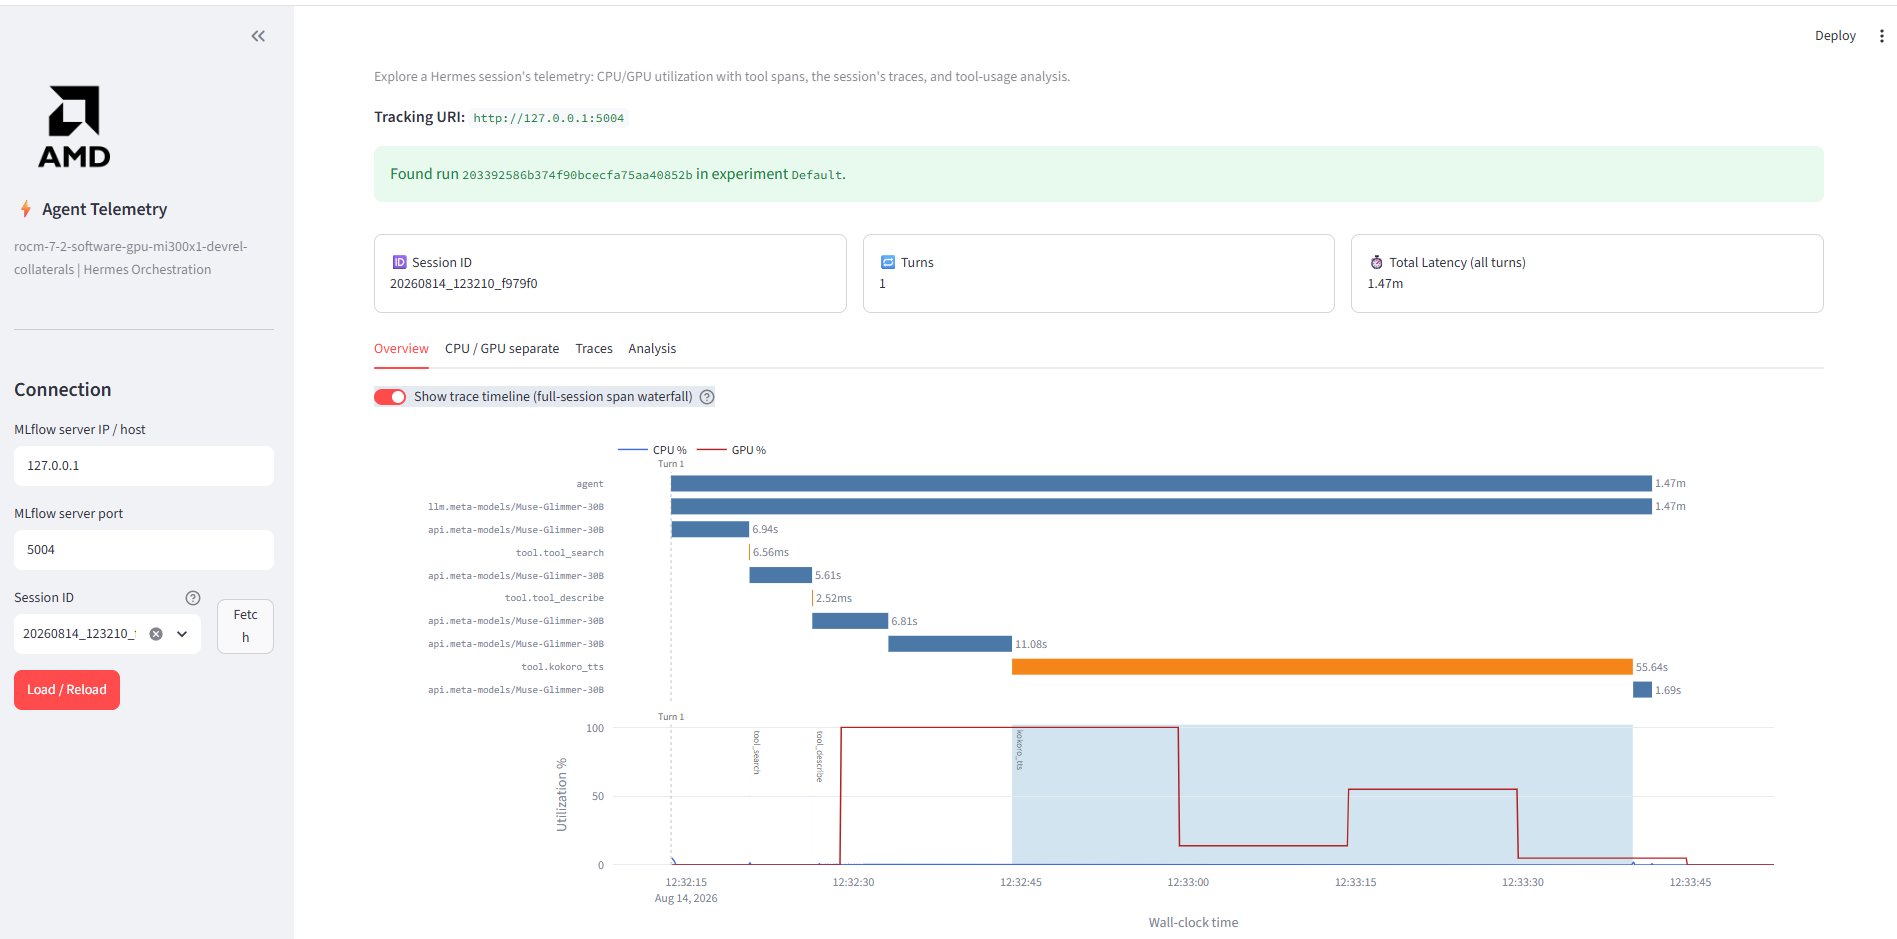

<details>
<summary><b>How this works under the hood</b></summary>

<br>

We extract these diagnostics directly from the MLflow trace. The UI parses the raw OTLP trace JSONs and compiles them into a clean, human-readable summary dashboard.

</details>


### How the local tool works

`kokoro_tts` uses the **Kokoro TTS model running locally on the AMD MI300X GPU**. It processes the input **one sentence at a time**, in sequence, and saves the synthesized speech as a **WAV** file - an uncompressed audio format that preserves the original quality.

### Observations - Why is it slow?

- In the dashboard, the **`kokoro_tts`** tool occupies the largest portion of the execution timeline, indicating that it is the primary contributor to the end-to-end latency.
- During the tool execution, **GPU utilization remains low for most of the run**, showing that the MI300X is not being fully utilized.
- Since sentences are processed **one at a time**, the GPU receives only a small amount of work in each inference, resulting in inefficient hardware utilization.
- As the number of input sentences increases, the tool executes more inference passes, causing the **overall latency to grow almost linearly**.
> The tool works and produces correct audio, but it clearly under-uses the GPU. That is the bottleneck the dashboard reveals - and the motivation to optimize the tool in the next step.

---
## Step 5 - Optimize the tool with batching

The dashboard showed the bottleneck: the tool feeds the GPU **one sentence at a time**. So we **edited `kokoro_tts` to add an optimized `batched` mode**.

Instead of processing the text one piece at a time (the original behavior, which we now call the **`sequential`** mode), the new **`batched`** mode groups many sentences together and sends them to the GPU in a single forward pass - giving the hardware much more work to do at once.

We re-run the exact same input, this time asking for `mode='batched'`, and compare.

In [2]:
!hermes chat --yolo -q "Use the kokoro_tts tool with the mode parameter set to 'batched', and pass the file path 'input_text.txt' as the text_file parameter. Do not read the file yourself"

Query: Use the kokoro_tts tool with the mode parameter set to 'batched', and 
pass the file path 'input_text.txt' as the text_file parameter. Do not read the 
file yourself
Initializing agent...
[hermes-otel] ✓ mlflow at http://127.0.0.1:5004/v1/traces (traces only)
[hermes-otel] ✓ Live dashboard store active
[hermes-otel] Registered 13 hooks
────────────────────────────────────────

⚠ Deprecated .env settings detected:
  ⚠ TERMINAL_CWD=/home/sabiras/new/hermes-audio-notebook found in .env — this is deprecated.
  Move to config.yaml instead:  terminal:\n    cwd: /your/project/path
  Then remove the old entries from ~/.hermes/.env

  ┊ ⚡ preparing tool_search…
  ┊ ⚡ tool_sear kokoro_tts  0.0s
  ┊ ⚡ preparing tool_describe…
  ┊ ⚡ tool_desc kokoro_tts  0.0s
  ┊ 💻 preparing terminal…
  ┊ 💻 $         ls -l input_text.txt  0.0s
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ preparing tool_call…
  ┊ ⚡ kokoro_tt   5.9s

╭─ ⚕ Hermes ───────────────────────────────────────────────────────────────────╮
Done. G

Load this run in the dashboard the same way as before - copy its Session ID and click **Load**. Then compare it side by side with the sequential run.

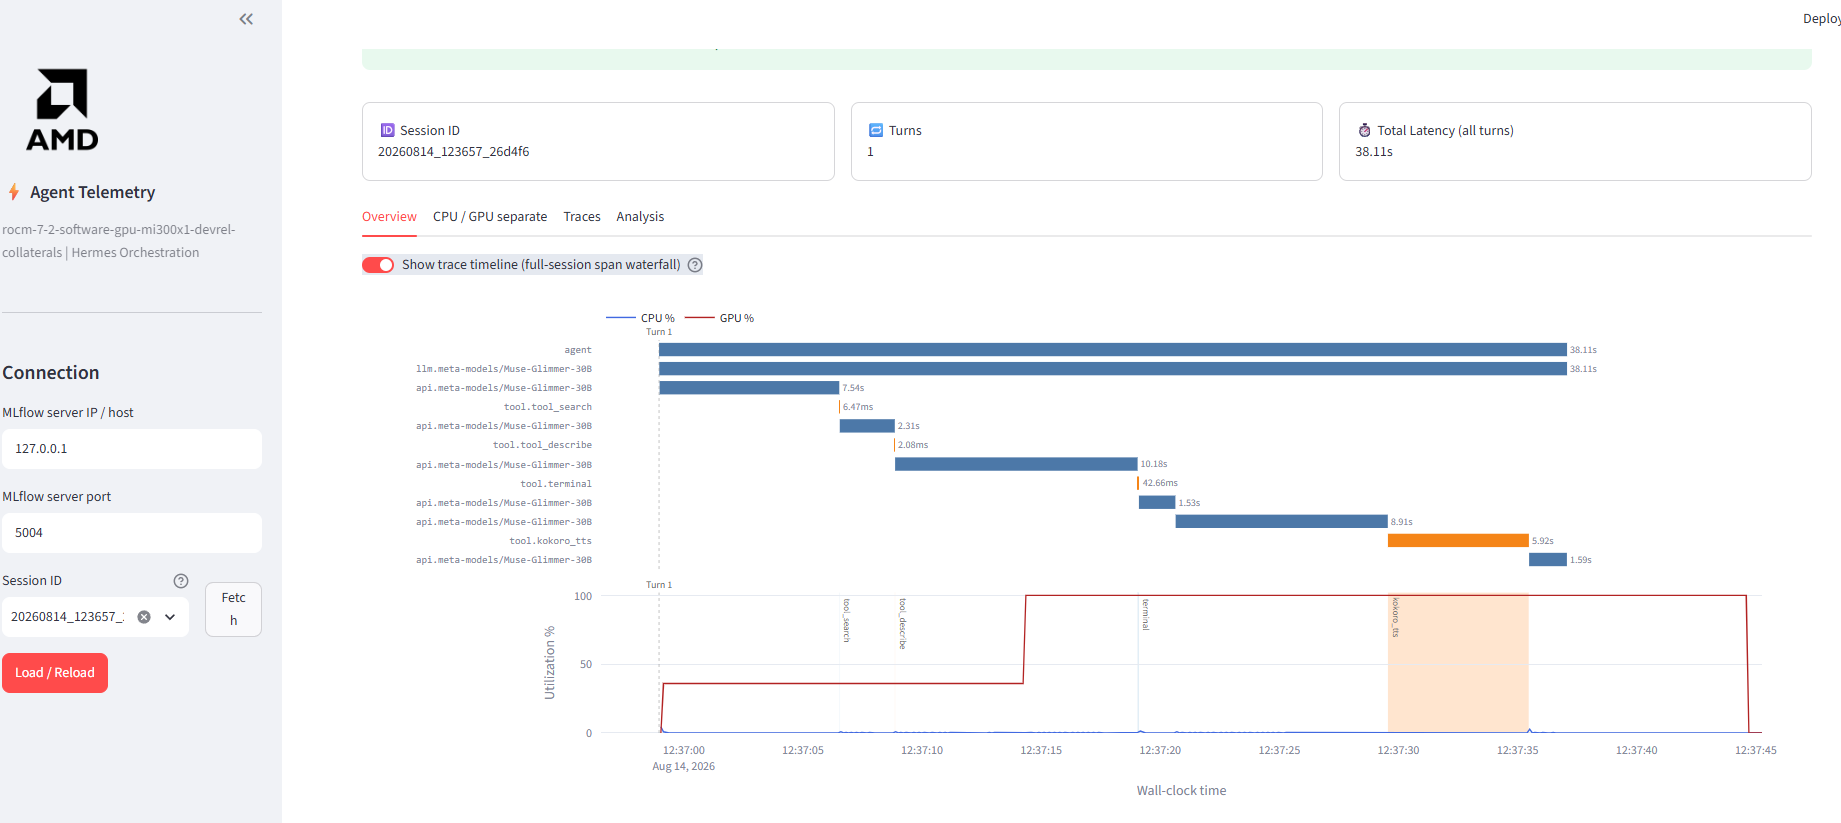

### Batched mode - How it works

Running `kokoro_tts` with `mode='batched'` uses our optimized implementation of Kokoro TTS. Since Kokoro does not support native batching, we modified the inference pipeline to process multiple sentences in a single GPU forward pass instead of processing them one at a time.

**Optimizations**

- **Batching:** Multiple sentences are grouped together, allowing the GPU to process more work in each forward pass and significantly improving hardware utilization.
- **Length Bucketing:** Sentences of similar lengths are grouped into the same batch, reducing unnecessary padding and improving efficiency.
- **Correct Batched Processing:** Padding and attention masks ensure that each sentence is processed independently, while the final audio is trimmed back to its original length. Refer to `kokoro_server.py` for the source code.

**Observations**

- With `mode='batched'`, **`kokoro_tts`** completes significantly faster than the sequential mode, demonstrating the benefit of processing multiple sentences in a single inference pass.
- During the highlighted tool execution, the GPU performs **more work per forward pass**, resulting in **better hardware utilization** and reduced overhead.
- Unlike the sequential mode, the GPU no longer spends time processing one sentence at a time. Instead, multiple sentences are processed together, reducing the number of GPU launches.
- CPU activity remains relatively low, indicating that the workload is primarily GPU-bound during speech synthesis.
- By reducing the number of inference passes, the overall tool execution time is significantly lower while producing the **same audio output**.
> This demonstrates that **batching improves throughput and GPU utilization**, making it the preferred mode for longer inputs.

---
## Step 6 - Visualize the improvement

Numbers in a dashboard are convincing, but a picture makes the win obvious. The following cell uses **Matplotlib** to plot the **inference time** of the two approaches side by side - the unoptimized `sequential` run against the optimized `batched` run - and annotates the speed-up.

> Set `seq_time` and `batched_time` to the **tool execution seconds** reported by your own two runs (shown in each tool's output line, for example `Inference: 5.65 s for 31 sentences`, and in the profiling dashboard). The values here are placeholders.

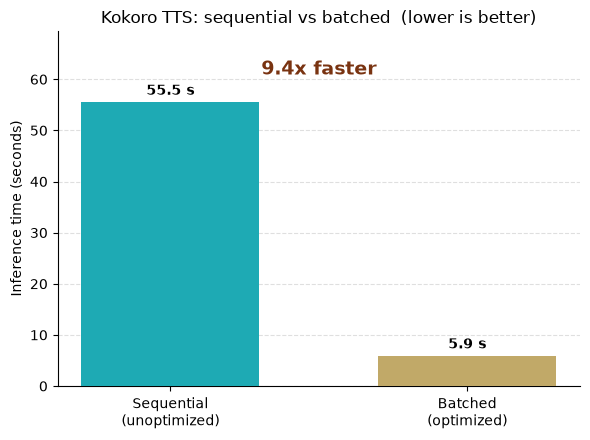

Sequential: 55.5s | Batched: 5.9s | Speedup: 9.4x


In [3]:
import os
import matplotlib.pyplot as plt

# --- Inference time (seconds) reported by each run ---
# Replace these with the "Inference" seconds from your own two runs
# (the tool prints e.g. "Inference: 5.65 s for 31 sentences").
seq_time = 55.5      # kokoro_tts, sequential mode  (unoptimized)
batched_time = 5.9  # kokoro_tts, batched mode     (optimized)

labels = ["Sequential\n(unoptimized)", "Batched\n(optimized)"]
times = [seq_time, batched_time]
colors = ["#1eaab4", "#c1a968"]

fig, ax = plt.subplots(figsize=(6, 4.5))
bars = ax.bar(labels, times, color=colors, width=0.6, zorder=3)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_ylabel("Inference time (seconds)")
ax.set_title("Kokoro TTS: sequential vs batched  (lower is better)")
ax.set_ylim(0, max(times) * 1.25)
ax.bar_label(bars, fmt="%.1f s", padding=3, fontweight="bold")

speedup = seq_time / batched_time if batched_time else 0
ax.text(0.5, 0.92, f"{speedup:.1f}x faster",
        transform=ax.transAxes, ha="center", va="top",
        fontsize=14, fontweight="bold", color="#793311")

for side in ("top", "right"):
    ax.spines[side].set_visible(False)

plt.tight_layout()
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/seq_vs_batched.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Sequential: {seq_time:.1f}s | Batched: {batched_time:.1f}s | "
      f"Speedup: {speedup:.1f}x")

---
## Try it on your own

Now that you have seen the full workflow, try it with your **own** content:

1. Open **`input_text.txt`** and replace its contents with any text you would like to synthesize - a paragraph, an article, or your own writing. The longer and more multi-sentence the text, the more clearly the batched speed-up shows.
2. **Save** the file.
3. Re-run the two synthesis cells above - `kokoro_tts` in the default (sequential) mode, then with `mode='batched'` - on your new text.
4. Open each run in the dashboard by its **Session ID**, then update the Matplotlib cell with your own inference times to visualize the comparison for your input.

> **Tip:** the bigger your input, the clearer the batched advantage - sequential time grows with the number of sentences, while batched keeps the GPU busy and stays fast.

---

## Conclusion and key takeaways

You just ran a complete, **observability-driven** optimization: you didn't *guess* what was slow, you **measured it in the dashboard** and fixed the real bottleneck.

| Phase | Tool | Where it runs | Outcome |
| :--- | :--- | :--- | :--- |
| **1 · Edge TTS** | `text_to_speech` | Cloud service | Truncates long text (~5 min); **incomplete** |
| **2 · Local Kokoro** | `kokoro_tts` | **Local**, MI300X, 1 sentence/pass | **Complete**, but slow; GPU underutilized |
| **3 · Optimized Kokoro** | `kokoro_tts` (`mode='batched'`) | **Local**, MI300X, many sentences/pass | **Complete** and much faster |

### What you learned

- **Cloud vs. local:** cloud tools are convenient but impose hard limits; a local model removes them and gives you full control of the hardware.
- **Measure, don't guess:** the telemetry dashboard showed *exactly* where time went and how busy the GPU was, for any Session ID.
- **GPU efficiency via batching:** batching lets the GPU process more work in each inference, reducing repeated launch overhead and improving overall throughput.
- **Iterate on your tools:** the same custom tool `kokoro_tts` started as a slow baseline and, once the dashboard exposed the bottleneck, we optimized it by adding a `batched` mode - and confirmed the win by measuring again.

### Handy extras

- **Raw MLflow UI (advanced):** you can also browse everything directly at `http://<server-ip>:5004`, under the **Traces** and **Runs** tabs.
- **Analysis tab:** click *Analyze with hermes* in the dashboard to get automatic, plain-language suggestions based on the run's `tool_breakdown.csv`.

<details>
<summary><b>Additional information: understanding the kernel cache</b></summary>

<br>

For a specific input:

- **First run (cold run):** the first execution is always a cold run, where the model compiles the required GPU kernels. This compilation overhead increases the execution time.
- **Subsequent runs:** from the second run onwards, the compiled kernels are reused from the cache, resulting in faster execution and lower latency.
- **Clearing the cache:** for Python-based executions, the kernel cache can be cleared using `clear_cache.sh`. In this workshop, however, Kokoro runs as a persistent server, so clearing the cache requires stopping the server, deleting the cache, and restarting the server before running the benchmark again.

**How does the cache work?**

MIOpen stores the compiled and tuned GPU kernels in its cache. With `MIOPEN_FIND_MODE=FAST`, MIOpen skips the expensive kernel search on subsequent runs and directly reuses the best-performing cached kernel. COMGR caches the LLVM compilation artifacts, avoiding recompilation of GPU code on future executions.

**Is the cache reused for every input?**

Not always. The cache is built for specific kernel configurations, which depend on factors such as the input shape (for example, sequence length or tensor dimensions). If a new input requires a kernel configuration that has not been compiled before, MIOpen will compile and cache it during that execution. Once cached, later runs with the same configuration can reuse it.

</details>

<details>
<summary><b>Troubleshooting</b></summary>

<br>

- **Can't reach a service in your browser (MLflow, dashboard, Jupyter, etc.):** the services bind to `localhost` on the server, so a remote browser cannot reach them directly. From a terminal on **your local machine**, forward the ports over SSH, then open the `http://localhost:<port>` URLs in your browser:

  ```bash
  ssh -L 8001:localhost:8001 -L 8092:localhost:8092 -L 5004:localhost:5004 -L 8501:localhost:8501 -L 8888:localhost:8888 <user>@<server-ip>
  ```

  Keep that SSH session open while you work. It forwards vLLM (8001), Kokoro (8092), MLflow (5004), the dashboard (8501), and Jupyter (8888).


- **Dashboard won't open / connection refused:** make sure the `helper.sh` terminal is still running, and that you used port **8501**.
- **"No run found with session_id":** the run may still be saving; wait a few seconds and click **Load** again. Confirm the MLflow settings are `127.0.0.1` / `5004`.
- **Session ID cell prints `None`:** telemetry flushes when the agent session ends; re-run the cell in a moment, or copy the ID from the run output.
- **Empty CPU/GPU charts:** the profiling patch or the GPU metrics exporter may not be active; check the `helper.sh` terminal for warnings.

</details>